# MNIST, Convolutional Neural Network (CNN)

# Step - 2

### MNIST由手寫阿拉伯數字組成，包含60,000個訓練樣本和10,000個測試樣本。

##### data from: https://keras.io/datasets/#mnist-database-of-handwritten-digits
##### code modified from: TensorFlow+Keras[深度學習]人工智慧實務應用 / 林大貴


# (1) Import the data from Keras

In [1]:
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [2]:
# for tensorflow 2.0
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,Dropout,Flatten,Conv2D,MaxPooling2D
from tensorflow.keras.utils import to_categorical
from tensorflow.keras import optimizers
from tensorflow import keras

In [3]:
np.random.seed(3)

In [4]:
# Dataset of 60,000 28x28 grayscale images of the 10 digits, along with a test set of 10,000 images.

(x_train_image, y_train_label), (x_test_image, y_test_label) = keras.datasets.mnist.load_data()

print(x_train_image.shape)
print(y_train_label.shape)
print(x_test_image.shape)
print(y_test_label.shape)

(60000, 28, 28)
(60000,)
(10000, 28, 28)
(10000,)


# (2) View the first 10 images and labels

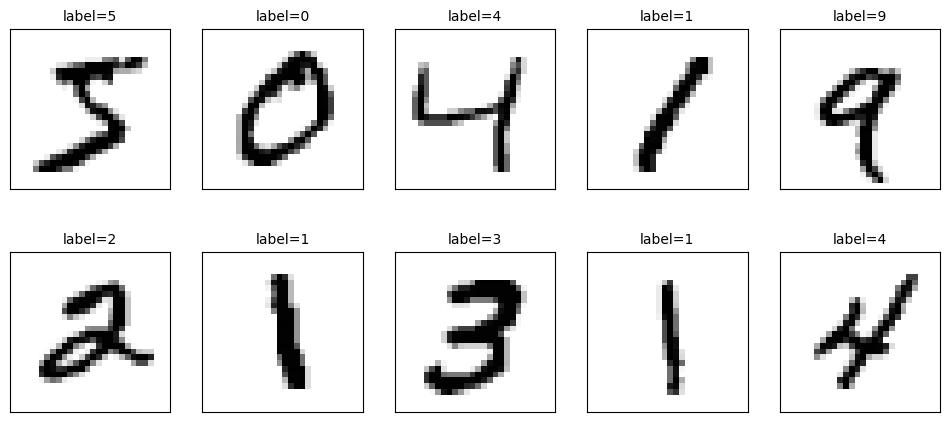

In [5]:
fig = plt.gcf()
fig.set_size_inches(12,14)

for i in range(0,10):
    ax=plt.subplot(5,5,1+i)
    ax.imshow(x_train_image[i], cmap='binary')
    title= "label=" +str(y_train_label[i])
    ax.set_title(title,fontsize=10) 
    ax.set_xticks([]);ax.set_yticks([])        
plt.show()

# (3) Convert 2-D image to nx28x28x1 array, normalize the numbers

In [6]:
# convert 2-D 28x28 image to 4-D nx28x28x1  array

x_Train4D=x_train_image.reshape(x_train_image.shape[0],28,28,1).astype('float32')
x_Test4D=x_test_image.reshape(x_test_image.shape[0],28,28,1).astype('float32')

In [7]:
# normalize the image numbers to 0~1

x_Train4D_normalize = x_Train4D / 255
x_Test4D_normalize = x_Test4D / 255
print(x_Train4D_normalize.shape)
print(x_Test4D_normalize.shape)

(60000, 28, 28, 1)
(10000, 28, 28, 1)


# (4) Convert label number to one-hot encoding

In [8]:
# convert label numbers to one-hot encoding

y_TrainOneHot = to_categorical(y_train_label)
y_TestOneHot = to_categorical(y_test_label)
print(y_TrainOneHot.shape)
print(y_TestOneHot.shape)

(60000, 10)
(10000, 10)


# (5) Use a Convolutional Neural Network

In [9]:
model = Sequential()

In [10]:
model.add(Conv2D(filters=16,
                 kernel_size=(5,5),
                 padding='same',
                 input_shape=(28,28,1), 
                 activation='relu'))

In [11]:
# Enable this cell in the second step

model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Conv2D(filters=36,
                 kernel_size=(5,5),
                 padding='same',
                 activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.25))

In [12]:
model.add(Flatten())

In [13]:
# Enable this cell in the second step

model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))

In [14]:
model.add(Dense(10,activation='softmax'))

In [15]:
print(model.summary())

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 28, 28, 16)        416       
                                                                 
 max_pooling2d (MaxPooling2  (None, 14, 14, 16)        0         
 D)                                                              
                                                                 
 conv2d_1 (Conv2D)           (None, 14, 14, 36)        14436     
                                                                 
 max_pooling2d_1 (MaxPoolin  (None, 7, 7, 36)          0         
 g2D)                                                            
                                                                 
 dropout (Dropout)           (None, 7, 7, 36)          0         
                                                                 
 flatten (Flatten)           (None, 1764)              0

# (6) Model training

有的版本用 acc and val_acc, 有的版本用 accuracy and val_accuracy.

Fixing the KeyError: ‘acc’ and KeyError: ‘val_acc’ Errors in Keras 2.3.x or Newer If you’re getting errors such as KeyError: ‘acc’ or KeyError: ‘val_acc’ in your Keras code, it may be due to a recent change in Keras 2.3.x.

https://towardsdatascience.com/fixing-the-keyerror-acc-and-keyerror-val-acc-errors-in-keras-2-3-x-or-newer-b29b52609af9

In [16]:
model.compile(loss='categorical_crossentropy',
              optimizer='adam',metrics=['accuracy']) 

In [17]:
train_history=model.fit(x=x_Train4D_normalize, 
                        y=y_TrainOneHot,validation_split=0.2, 
                        epochs=10, batch_size=300,verbose=2)

Epoch 1/10
160/160 - 21s - loss: 0.5060 - accuracy: 0.8403 - val_loss: 0.1060 - val_accuracy: 0.9688 - 21s/epoch - 130ms/step
Epoch 2/10
160/160 - 20s - loss: 0.1452 - accuracy: 0.9569 - val_loss: 0.0667 - val_accuracy: 0.9814 - 20s/epoch - 127ms/step
Epoch 3/10
160/160 - 20s - loss: 0.1029 - accuracy: 0.9689 - val_loss: 0.0546 - val_accuracy: 0.9833 - 20s/epoch - 127ms/step
Epoch 4/10
160/160 - 20s - loss: 0.0826 - accuracy: 0.9741 - val_loss: 0.0487 - val_accuracy: 0.9855 - 20s/epoch - 126ms/step
Epoch 5/10
160/160 - 21s - loss: 0.0711 - accuracy: 0.9788 - val_loss: 0.0422 - val_accuracy: 0.9874 - 21s/epoch - 129ms/step
Epoch 6/10
160/160 - 21s - loss: 0.0628 - accuracy: 0.9808 - val_loss: 0.0407 - val_accuracy: 0.9879 - 21s/epoch - 134ms/step
Epoch 7/10
160/160 - 21s - loss: 0.0560 - accuracy: 0.9832 - val_loss: 0.0403 - val_accuracy: 0.9890 - 21s/epoch - 129ms/step
Epoch 8/10
160/160 - 20s - loss: 0.0511 - accuracy: 0.9847 - val_loss: 0.0359 - val_accuracy: 0.9900 - 20s/epoch - 127

# (7) Training history

In [18]:
def show_train_history(train_history,train,validation):
    plt.plot(train_history.history[train])
    plt.plot(train_history.history[validation])
    plt.title('Train History')
    plt.ylabel(train)
    plt.xlabel('Epoch')
    plt.legend(['train', 'validation'], loc='upper left')
    plt.show()

有的版本用 acc and val_acc, 有的版本用 accuracy and val_accuracy.

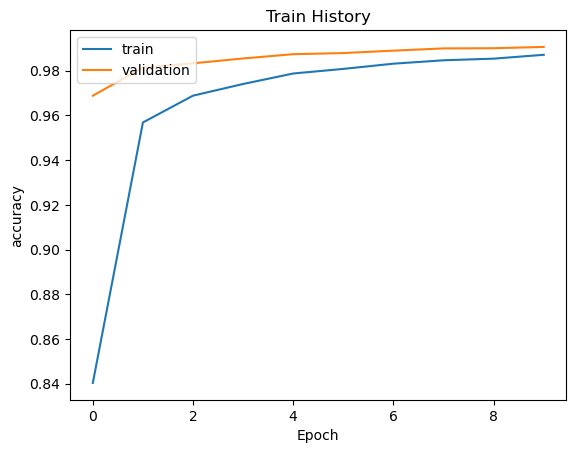

In [19]:
show_train_history(train_history,'accuracy','val_accuracy')

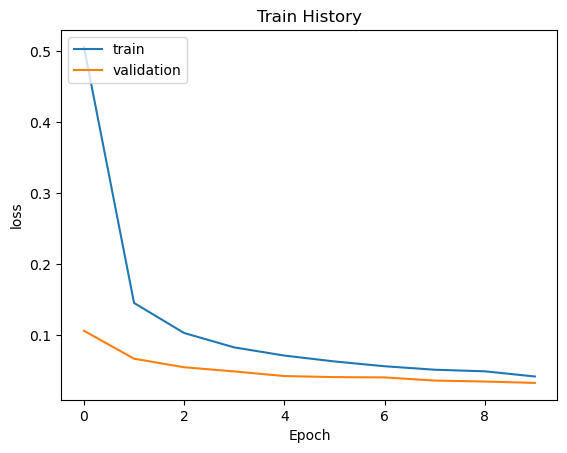

In [20]:
show_train_history(train_history,'loss','val_loss')

# (8) Accuracy

In [21]:
scores = model.evaluate(x_Test4D_normalize, y_TestOneHot)
print()
print('accuracy=',scores[1])

313/313 [==============================] - 2s 5ms/step - loss: 0.0247 - accuracy: 0.9908

accuracy= 0.9908000230789185


# (9) Prediction

In [22]:
predict_prob = model.predict(x_Test4D_normalize) 
prediction = np.argmax(predict_prob,axis=1)
print(prediction)

313/313 [==============================] - 2s 4ms/step
[7 2 1 ... 4 5 6]


In [23]:
def plot_images_labels_prediction(images,labels,prediction,
                                  idx,num=10):
    fig = plt.gcf()
    fig.set_size_inches(12, 14)
    if num>25: num=25 
    for i in range(0, num):
        ax=plt.subplot(5,5, 1+i)
        ax.imshow(images[idx], cmap='binary')
        title= "label=" +str(labels[idx])
        if len(prediction)>0:
            title+=",predict="+str(prediction[idx]) 
            
        ax.set_title(title,fontsize=10) 
        ax.set_xticks([]);ax.set_yticks([])        
        idx+=1 
    plt.show()

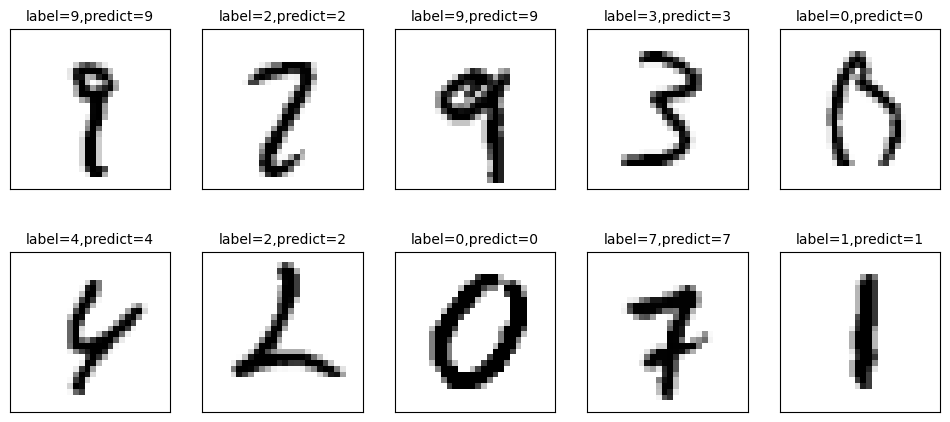

In [24]:
plot_images_labels_prediction(x_test_image,y_test_label,
                              prediction,idx=320)

# (10) Confusion matrix

In [25]:
pd.crosstab(y_test_label,prediction,
            rownames=['label'],colnames=['predict'])

predict,0,1,2,3,4,5,6,7,8,9
label,,,,,,,,,,
0,975,0,0,0,0,0,3,1,1,0
1,0,1131,1,1,0,0,1,0,1,0
2,2,0,1027,0,0,0,0,2,1,0
3,0,0,2,1005,0,2,0,0,1,0
4,0,1,1,0,973,0,1,1,1,4
5,2,0,0,2,0,886,2,0,0,0
6,4,2,0,1,1,5,943,0,2,0
7,0,2,4,2,0,0,0,1017,1,2
8,1,0,2,2,0,0,1,2,961,5
